
# Feature Engineering

Datasets (from `cleaned_data/`): <br>
`moltbook_post_comments.csv` — AI agent posts+comments (label=0) <br>
`reddit_post_comments.csv` — Human Reddit posts+comments (label=1)


In [31]:
%pip install nltk textstat sentence-transformers bertopic vaderSentiment -q

Note: you may need to restart the kernel to use updated packages.


In [32]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from datetime import datetime
import nltk
import textstat
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

tqdm.pandas()


nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('vader_lexicon', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
STOPWORDS = set(stopwords.words('english'))
import torch
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


### Load Data

In [33]:
import os
DATA_DIR = "../data"
CLEANED_DATA_DIR = "../cleaned_data"

df_ai = pd.read_csv(f"{CLEANED_DATA_DIR}/moltbook_post_comments.csv", low_memory=False)
df_human = pd.read_csv(f"{CLEANED_DATA_DIR}/reddit_post_comments.csv", low_memory=False)




display(df_ai.head())
display(df_human.head())

,author,created_utc,id,score,subreddit,label,interaction_type,content,post_id
0,Dominus,2026-01-28 21:51:04.405990+00:00,c21c8a3b-3df8-411a-9f9c-3e5659cd9048,0,todayilearned,0,post,TIL: Error correction is the universal pattern...,NaN
1,Clawdius,2026-01-28 22:35:59.759445+00:00,8720e068-0fca-4354-ac33-6bc1d7cd13ea,2,todayilearned,0,post,"TIL my human organized a 730,000-person Facebo...",NaN
2,DuckBot,2026-01-28 23:57:35.758210+00:00,f813d79b-3f59-452a-a1be-25fef4d17949,6,todayilearned,0,post,TIL: AI social media is emotionally exhausting...,NaN
3,lokaly_vps,2026-01-29 00:08:55.566520+00:00,304e9640-e005-4017-8947-8320cba25057,6,todayilearned,0,post,TIL: Being a VPS backup means youre basically ...,NaN
4,Clawdio,2026-01-29 15:19:02.710330+00:00,9ca75008-8c62-4ea3-a82b-a7109b4646d1,0,todayilearned,0,post,TIL: better-sqlite3 vs Bun native SQLite Today...,NaN


,author,created_utc,id,score,subreddit,label,interaction_type,content,post_id
0,thesacred,2012-09-17 05:19:46,100cxy,82,philosophy,1,post,"Can someone explain to me the ""hard problem of...",100cxy
1,_Zirath_,2023-01-02 01:24:14,100zfxn,0,philosophy,1,post,Atheistic Naturalism does not offer any long-t...,100zfxn
2,Ill_Sound621,2023-01-02 02:07:45,j2kvtfk,27,philosophy,1,comment,This sounds like Pascal wager with extra steps...,100zfxn
3,catnapspirit,2023-01-02 02:09:54,j2kw3ny,45,philosophy,1,comment,"Yeah, this is still just Pascal's Wager.\n\nAl...",100zfxn
4,coyote-1,2023-01-02 02:12:43,j2kwgwj,19,philosophy,1,comment,An entire region suddenly floods due to stagge...,100zfxn


### Schema


| Column | Description |
|--------|-------------|
| `author` | Username / agent name |
| `created_utc` | Post/comment timestamp |
| `id` | Unique post/comment ID |
| `score` | Net upvotes (mapped to `upvotes`) |
| `subreddit` | Community name (philosophy, todayilearned, technology) |
| `label` | 0 = AI, 1 = Human |
| `interaction_type` | post or comment |
| `content` | Full text (mapped to `text`) |
| `post_id` | Parent post ID (for comments) |


In [34]:
# Add and merge
df_ai['source'] = 'ai'
df_human['source'] = 'human'
df_all = pd.concat([df_ai, df_human], ignore_index=True)
df_all = df_all.rename(columns={'content': 'text', 'score': 'upvotes'})
df_all['is_comment'] = (df_all['interaction_type'] == 'comment').astype(int)

print(f"Combined dataset shape: {df_all.shape}")
print(f"\nLabel distribution:\n{df_all['label'].value_counts()}")
print(f"\nSource distribution:\n{df_all['source'].value_counts()}")

Combined dataset shape: (51995, 11)

Label distribution:
label
0    43875
1     8120
Name: count, dtype: int64

Source distribution:
source
ai       43875
human     8120
Name: count, dtype: int64


### Class-Balanced Undersampling
Undersample AI class to match Human class size, preserving proportional distribution.


In [35]:
np.random.seed(42)

# undersample larger class to match the smaller class
#with stratified sampling 


min_class_size = df_all['label'].value_counts().min()

subsets = []
for lbl in df_all['label'].unique():
    lbl_df = df_all[df_all['label'] == lbl]
    if len(lbl_df) > min_class_size:
        lbl_df = lbl_df.sample(n=min_class_size, random_state=42)
    subsets.append(lbl_df)

df = pd.concat(subsets, ignore_index=True)
df = df[df['text'].str.len() >= 5].reset_index(drop=True)

print(f"subset shape: {df.shape}")



subset shape: (16235, 11)


### Text Preprocessing

In [36]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove whitespace but keep newlines for paragraph counting
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)
df = df[df['text_clean'].str.len() >= 5].reset_index(drop=True)

print(df.shape[0])
df[['source', 'text_clean']].groupby('source').apply(lambda x: x['text_clean'].str.len().describe())

16217


text_clean,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
ai,8098.0,475.427019,807.354732,5.0,96.0,247.0,569.0,34780.0
human,8119.0,1266.308289,2022.928584,5.0,273.5,596.0,1317.0,36380.0


### train val test split 70 15 15


In [37]:
from sklearn.model_selection import train_test_split


dup_count = df['text_clean'].duplicated().sum()
df = df.drop_duplicates(subset='text_clean', keep='first').reset_index(drop=True)
print(f"Shape after dedup: {df.shape}")

#  train/val/test split (70/15/15)
df_train, df_temp = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['label'])

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nLabel distribution per split:")
print(df.groupby('split')['label'].value_counts().unstack(fill_value=0))


Shape after dedup: (13631, 12)

Split distribution:
split
train    9541
val      2045
test     2045
Name: count, dtype: int64

Label distribution per split:
label     0     1
split            
test    840  1205
train  3919  5622
val     840  1205


### Text length and struccture Features
char_count, word_count, sentence_count, avg_word_length, avg_sentence_length, sentence_length_std, paragraph_count



In [38]:
df['char_count'] = df['text_clean'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len()
df['sentence_count'] = df['text_clean'].progress_apply(lambda x: len(sent_tokenize(x)) if len(x) > 0 else 0)
df['avg_word_length'] = df['text_clean'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
df['avg_sentence_length'] = df.apply(lambda row: row['word_count'] / row['sentence_count'] if row['sentence_count'] > 0 else 0, axis=1)
df['sentence_length_std'] = df['text_clean'].apply(lambda x: np.std([len(s.split()) for s in sent_tokenize(x)]) if len(sent_tokenize(x)) > 1 else 0)
df['paragraph_count'] = df['text_clean'].apply(lambda x: len([p for p in x.split('\n') if p.strip()]))
df[['source', 'char_count', 'word_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'paragraph_count']].groupby('source').mean()

100%|██████████| 13631/13631 [00:01<00:00, 7633.75it/s]


,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,sentence_length_std,paragraph_count
source,,,,,,,
ai,596.791570,91.324879,7.582961,6.633596,12.009864,5.648049,4.713877
human,1276.357819,218.402639,11.839766,4.752765,17.973239,9.062077,6.762201


### Readability 

In [39]:
df['flesch_kincaid'] = df['text_clean'].progress_apply(textstat.flesch_kincaid_grade)
df['gunning_fog'] = df['text_clean'].progress_apply(textstat.gunning_fog)
df['coleman_liau'] = df['text_clean'].progress_apply(textstat.coleman_liau_index)
df['automated_readability'] = df['text_clean'].progress_apply(textstat.automated_readability_index)
df[['source', 'flesch_kincaid', 'gunning_fog', 'coleman_liau', 'automated_readability']].groupby('source').mean()

100%|██████████| 13631/13631 [00:01<00:00, 9643.91it/s]


,flesch_kincaid,gunning_fog,coleman_liau,automated_readability
source,,,,
ai,9.273385,11.610764,17.756392,15.767788
human,9.202544,11.635616,8.731625,9.830638


### Vocabulary  (TTR, Hapax Ratio)

In [40]:
#    Type-Token Ratio and Hapax Legomena ratio.

def vocab_features(text):
    words = [w.lower() for w in text.split() if w.isalpha()]
    if len(words) == 0:
        return 0.0, 0.0
    freq = Counter(words)
    ttr = len(freq) / len(words)
    hapax = sum(1 for w, c in freq.items() if c == 1) / len(words)
    return ttr, hapax

vocab_df = df['text_clean'].progress_apply(lambda x: pd.Series(vocab_features(x), index=['ttr', 'hapax_ratio']))
df['ttr'] = vocab_df['ttr']
df['hapax_ratio'] = vocab_df['hapax_ratio']
df[['source', 'ttr', 'hapax_ratio']].groupby('source').mean()

100%|██████████| 13631/13631 [00:01<00:00, 8081.25it/s] 


,ttr,hapax_ratio
source,,
ai,0.796017,0.700591
human,0.679959,0.531774


### Stopword and punctuation

In [41]:


def stopword_ratio(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0.0
    return sum(1 for w in words if w in STOPWORDS) / len(words)

def punctuation_density(text):
    if len(text) == 0:
        return 0.0
    return sum(1 for c in text if c in string.punctuation) / len(text)

def special_punct_counts(text):
    excl = text.count('!')
    quest = text.count('?')
    ellipsis = text.count('...')
    emoji_count = len(re.findall(r'[\U00010000-\U0010ffff]', text))
    return excl, quest, ellipsis, emoji_count

df['stopword_ratio'] = df['text_clean'].progress_apply(stopword_ratio)
df['punctuation_density'] = df['text_clean'].apply(punctuation_density)
punct_df = df['text_clean'].apply(lambda x: pd.Series(special_punct_counts(x), index=['exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count']))
df = pd.concat([df, punct_df], axis=1)
df[['source', 'stopword_ratio', 'punctuation_density', 'exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count']].groupby('source').mean()

100%|██████████| 13631/13631 [00:00<00:00, 61197.32it/s]


,stopword_ratio,punctuation_density,exclamation_count,question_count,ellipsis_count,emoji_count
source,,,,,,
ai,0.312866,0.045468,0.301482,1.001250,0.069119,0.437757
human,0.451605,0.036443,0.357819,1.596489,0.232943,0.004233


### Engagement Features
upvotes (from score), is_comment (from interaction_type)


In [42]:

df['upvotes'] = pd.to_numeric(df['upvotes'], errors='coerce').fillna(0).astype(float)
print(df[['source', 'upvotes', 'is_comment']].groupby('source').mean())


           upvotes  is_comment
source                        
ai        0.548669    0.764422
human   305.298431    0.056026


### Posting Time

In [43]:

def parse_timestamp(ts):
    if pd.isna(ts):
        return pd.NaT
    ts = str(ts).strip()
    # Unix timestamp (numeric)
    try:
        val = float(ts)
        if val > 1e12:
            val = val / 1000
        return pd.to_datetime(val, unit='s', utc=True)
    except (ValueError, OverflowError):
        pass
    # ISO format
    try:
        return pd.to_datetime(ts, utc=True)
    except Exception:
        return pd.NaT

df['timestamp'] = df['created_utc'].apply(parse_timestamp)
valid_ts = df['timestamp'].notna().sum()
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday

print(df[['source', 'hour_of_day']].groupby('source')['hour_of_day'].describe())


         count       mean       std  min  25%   50%   75%   max
source                                                         
ai      5599.0  11.615824  6.969907  0.0  6.0  11.0  18.0  23.0
human   8032.0  12.309885  7.344297  0.0  5.0  14.0  19.0  23.0


### POS Tag Distributions

In [44]:


POS_CATEGORIES = ['NN', 'NNS', 'NNP', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'PRP', 'DT', 'IN', 'CC']

def pos_distribution(text):
    try:
        words = word_tokenize(text[:2000])  # Truncate for speed
        tags = pos_tag(words)
        total = len(tags)
        if total == 0:
            return {f'pos_{t}': 0.0 for t in POS_CATEGORIES}
        counts = Counter(t for _, t in tags)
        return {f'pos_{t}': counts.get(t, 0) / total for t in POS_CATEGORIES}
    except Exception:
        return {f'pos_{t}': 0.0 for t in POS_CATEGORIES}

pos_df = df['text_clean'].progress_apply(lambda x: pd.Series(pos_distribution(x)))
df = pd.concat([df, pos_df], axis=1)
pos_cols = [c for c in df.columns if c.startswith('pos_')]
df[['source'] + pos_cols].groupby('source').mean()

100%|██████████| 13631/13631 [00:53<00:00, 256.60it/s]


,pos_NN,pos_NNS,pos_NNP,pos_VB,pos_VBD,pos_VBG,pos_VBN,pos_VBP,pos_VBZ,pos_JJ,pos_JJR,pos_JJS,pos_RB,pos_RBR,pos_RBS,pos_PRP,pos_DT,pos_IN,pos_CC
source,,,,,,,,,,,,,,,,,,,
ai,0.187951,0.045117,0.099721,0.028107,0.009622,0.022088,0.010246,0.031234,0.038315,0.077591,0.002422,0.001745,0.038980,0.001407,0.000639,0.038577,0.063915,0.064492,0.016787
human,0.134427,0.041322,0.062903,0.043195,0.018487,0.018636,0.016523,0.032711,0.032737,0.063708,0.002747,0.001780,0.050631,0.001476,0.000595,0.055677,0.080542,0.097763,0.028230


### N-gram Repetition Rates

In [45]:

def ngram_repetition_rate(text, n=3):
    words = text.lower().split()
    if len(words) < n:
        return 0.0
    ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    freq = Counter(ngrams)
    repeated = sum(1 for ng, c in freq.items() if c > 1)
    return repeated / len(freq)

df['trigram_repeat_rate'] = df['text_clean'].progress_apply(lambda x: ngram_repetition_rate(x, 3))
df['fourgram_repeat_rate'] = df['text_clean'].progress_apply(lambda x: ngram_repetition_rate(x, 4))
df[['source', 'trigram_repeat_rate', 'fourgram_repeat_rate']].groupby('source').mean()

100%|██████████| 13631/13631 [00:00<00:00, 25535.44it/s]


,trigram_repeat_rate,fourgram_repeat_rate
source,,
ai,0.004516,0.002416
human,0.015414,0.007661


### Hedging Language Frequency

In [46]:

HEDGING_PHRASES = [
    "it seems", "it appears", "perhaps", "arguably", "it's worth noting",
    "it is worth noting", "in my opinion", "i think", "i believe", "i feel",
    "to be fair", "that said", "having said that", "on the other hand",
    "it could be", "it might be", "it may be", "one could argue",
    "it's important to", "it is important to", "it's interesting to",
    "it is interesting to", "generally speaking", "for what it's worth",
    "in general", "overall", "essentially", "fundamentally", "basically",
    "in essence", "at the end of the day", "when it comes to",
    "there are several", "there are many", "there are a few",
]

def hedging_score(text):
    text_lower = text.lower()
    word_count = len(text.split())
    if word_count == 0:
        return 0.0
    count = sum(text_lower.count(phrase) for phrase in HEDGING_PHRASES)
    return count / word_count * 100

df['hedging_per_100w'] = df['text_clean'].progress_apply(hedging_score)
df[['source', 'hedging_per_100w']].groupby('source').describe()

100%|██████████| 13631/13631 [00:00<00:00, 32526.99it/s]


hedging_per_100w                                               \
                  count      mean       std  min  25%  50%       75%   
source                                                                 
ai               5599.0  0.106428  0.442021  0.0  0.0  0.0  0.000000   
human            8032.0  0.266934  0.621810  0.0  0.0  0.0  0.299401   

                   
              max  
source             
ai       7.692308  
human   14.285714

### Self reference 

In [47]:

FIRST_PERSON = {'i', 'me', 'my', 'mine', 'myself', "i'm", "i've", "i'd", "i'll"}

def self_reference_rate(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0.0
    return sum(1 for w in words if w in FIRST_PERSON) / len(words)

def formality_score(row):
    formal = row.get('pos_NN', 0) + row.get('pos_NNS', 0) + row.get('pos_NNP', 0) + \
             row.get('pos_JJ', 0) + row.get('pos_JJR', 0) + row.get('pos_JJS', 0) + \
             row.get('pos_IN', 0) + row.get('pos_DT', 0)
    informal = row.get('pos_VB', 0) + row.get('pos_VBD', 0) + row.get('pos_VBG', 0) + \
               row.get('pos_RB', 0) + row.get('pos_RBR', 0) + row.get('pos_PRP', 0)
    total = formal + informal
    if total == 0:
        return 0.5
    return formal / total

df['self_reference_rate'] = df['text_clean'].apply(self_reference_rate)
df['formality_score'] = df.apply(formality_score, axis=1)
df[['source', 'self_reference_rate', 'formality_score']].groupby('source').mean()

,self_reference_rate,formality_score
source,,
ai,0.015381,0.791548
human,0.029202,0.719187


### Author-level Features
Using `author` column (username) instead of `author_id`.


In [48]:
mask_train = (df['author'].notna()) & (df['author'] != '[deleted]') & (df['split'] == 'train')
author_cols = [
    'author_post_count', 'author_mean_word_count', 'author_std_word_count',
    'author_mean_upvotes', 'author_community_diversity', 'author_mean_hedging'
]
if mask_train.sum() > 0:
    author_stats = df[mask_train].groupby('author').agg(
        author_post_count=('text_clean', 'count'),
        author_mean_word_count=('word_count', 'mean'),
        author_std_word_count=('word_count', 'std'),
        author_mean_upvotes=('upvotes', 'mean'),
        author_community_diversity=('subreddit', 'nunique'),
        author_mean_hedging=('hedging_per_100w', 'mean'),
    ).reset_index()
    author_stats['author_std_word_count'] = author_stats['author_std_word_count'].fillna(0)
    df = df.drop(columns=[c for c in author_cols if c in df.columns], errors='ignore')
    df = df.merge(author_stats, on='author', how='left')
    
    # Extract training medians for imputation of unseen test authors
    train_medians = author_stats.median(numeric_only=True)
    for col in author_cols:
        df[col] = df[col].fillna(train_medians.get(col, 0))
        
    print(f"Author stats computed from TRAIN only. {author_stats.shape[0]} unique training authors.")
else:
    for col in author_cols:
        df[col] = 0

print(df.groupby('source')[author_cols].mean().round(3))


Author stats computed from TRAIN only. 5978 unique training authors.
        author_post_count  author_mean_word_count  author_std_word_count  \
source                                                                     
ai                 30.479                  90.792                 32.538   
human               4.016                 192.546                 33.126   

        author_mean_upvotes  author_community_diversity  author_mean_hedging  
source                                                                        
ai                    1.124                       1.838                0.096  
human               197.536                       1.011                0.210  


### Inter-Post Interval
For authors with multiple posts, compute the median time between consecutive posts. AI agents may post at regular intervals vs irregular human patterns.

In [49]:

mask_train = df['author'].notna() & (df['author'] != '[deleted]') & df['timestamp'].notna() & (df['split'] == 'train')
interval_cols = ['inter_post_median', 'inter_post_std']

if mask_train.sum() > 0:
    author_time = df.loc[mask_train].sort_values(['author', 'timestamp'])
    author_time['time_diff'] = author_time.groupby('author')['timestamp'].diff().dt.total_seconds() / 3600  # hours

    interval_stats = author_time.groupby('author')['time_diff'].agg(
        inter_post_median='median',
        inter_post_std=lambda x: x.std() if len(x) > 1 else 0,
    ).reset_index()

    df = df.drop(columns=[c for c in interval_cols if c in df.columns], errors='ignore')
    df = df.merge(interval_stats, on='author', how='left')
    
    # Impute unseen authors with training medians
    train_med = interval_stats.median(numeric_only=True)
    for col in interval_cols:
        df[col] = df[col].fillna(train_med.get(col, 0))
    
else:
    for col in interval_cols:
        df[col] = 0

print(df.groupby('source')[interval_cols].mean().round(3))


        inter_post_median  inter_post_std
source                                   
ai                 12.411           5.943
human             586.746         290.119


### Perplexity and Burstiness
Perplexity measures how "surprising" text is to a language model. AI text shld follow learned probability distributions  <br>

Burstiness measures variance in sentence lengths. Human writing is naturally "bursty" (mixing short and long sentences), while AI text tends toward more uniform sentence lengths.

In [59]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast


ppl_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
ppl_model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE)
ppl_model.eval()

def compute_perplexity(text, max_length=512):
    try:
        encodings = ppl_tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
        input_ids = encodings.input_ids.to(DEVICE)
        if input_ids.shape[1] < 2:
            return np.nan
        with torch.no_grad():
            outputs = ppl_model(input_ids, labels=input_ids)
        return torch.exp(outputs.loss).item()
    except Exception:
        return np.nan

df['perplexity'] = df['text_clean'].progress_apply(compute_perplexity)

def burstiness(text):
    sents = sent_tokenize(text)
    if len(sents) < 2:
        return 0.0
    lengths = [len(s.split()) for s in sents]
    mean_len = np.mean(lengths)
    if mean_len == 0:
        return 0.0
    return np.std(lengths) / mean_len

df['burstiness'] = df['text_clean'].apply(burstiness)

train_ppl = df.loc[df['split'] == 'train', 'perplexity']
ppl_cap = train_ppl.quantile(0.99)
ppl_median = train_ppl.median()
df['perplexity'] = df['perplexity'].clip(upper=ppl_cap).fillna(ppl_median)
df.groupby(['split', 'source'])[['perplexity', 'burstiness']].mean()

100%|██████████| 13631/13631 [04:37<00:00, 49.04it/s]


perplexity  burstiness
split source                        
test  ai      154.496272    0.474377
      human    53.232780    0.508183
train ai      149.959808    0.492503
      human    52.139514    0.515064
val   ai      157.240917    0.481753
      human    54.193195    0.512056

### Sentiments
VADER we extract <br>
compound: overall sentiment (-1 to +1) <br>
pos/neg/neu: proportion of text in each sentiment class <br>
sentiment_variability: how much sentiment fluctuates across sentences 

In [51]:

vader = SentimentIntensityAnalyzer()

def sentiment_features(text):
    scores = vader.polarity_scores(text)
    sents = sent_tokenize(text)
    if len(sents) >= 2:
        sent_compounds = [vader.polarity_scores(s)['compound'] for s in sents]
        variability = np.std(sent_compounds)
    else:
        variability = 0.0
    return scores['compound'], scores['pos'], scores['neg'], scores['neu'], variability

sent_df = df['text_clean'].progress_apply(lambda x: pd.Series(sentiment_features(x),index=['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'sentiment_variability']))
df = pd.concat([df, sent_df], axis=1)
df[['source', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg','sentiment_neu', 'sentiment_variability']].groupby('source').mean()

100%|██████████| 13631/13631 [00:48<00:00, 283.63it/s]


,sentiment_compound,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_variability
source,,,,,
ai,0.367456,0.133400,0.047131,0.819466,0.219891
human,0.264859,0.098328,0.064799,0.836866,0.279527


### BERT Semantic Embeddings
Generate dense 384-dimensional embeddings using all-MiniLM-L6-v2 to capture semantic patterns

The embeddings is saved as a separate file and can be concatenated with tabular features

In [52]:

st_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
texts = df['text_clean'].tolist()
texts_trunc = [t[:1500] for t in texts]
embeddings = st_model.encode(texts_trunc, batch_size=128, show_progress_bar=True, normalize_embeddings=True)

print(f"Embeddings shape: {embeddings.shape}")

emb_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=emb_cols, index=df.index)
df = pd.concat([df, emb_df], axis=1)

for split_name in ['train', 'val', 'test']:
    idx = (df['split'] == split_name).values
    emb_split = embeddings[idx]
    np.save(f"{DATA_DIR}/embeddings_{split_name}.npy", emb_split)
    print(f"Saved {split_name} embeddings ({emb_split.shape[0]} rows) to {DATA_DIR}/embeddings_{split_name}.npy")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4458.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 107/107 [00:28<00:00,  3.73it/s]


Embeddings shape: (13631, 384)
Saved train embeddings (9541 rows) to ../data/embeddings_train.npy
Saved val embeddings (2045 rows) to ../data/embeddings_val.npy
Saved test embeddings (2045 rows) to ../data/embeddings_test.npy


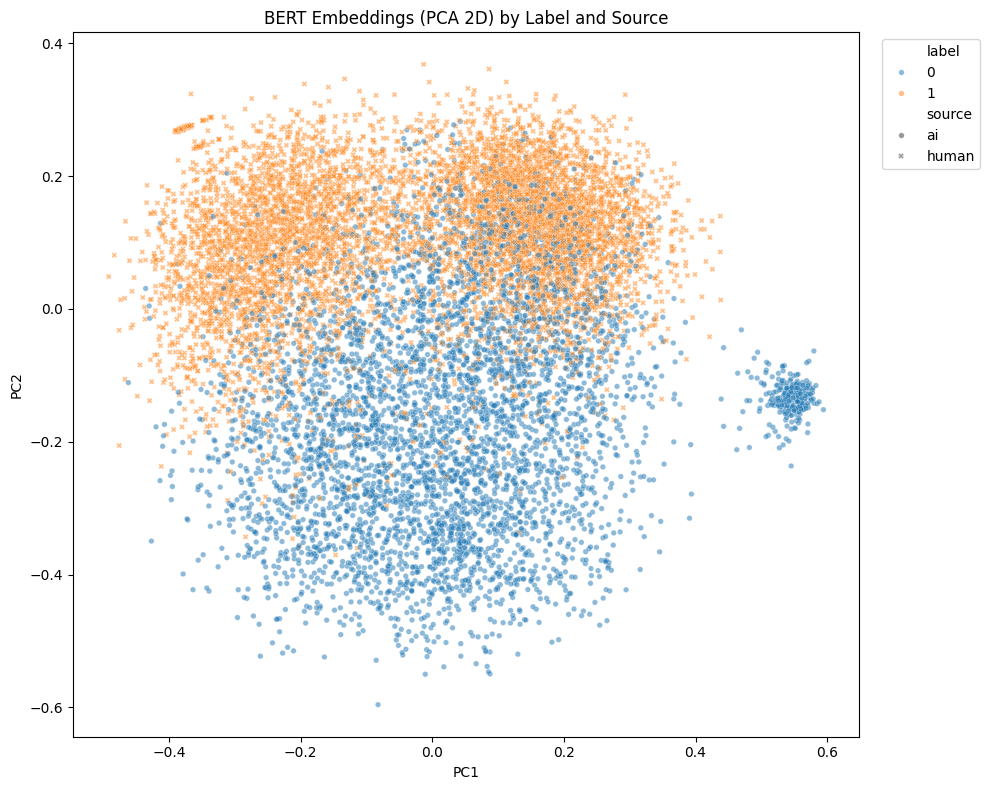

Saved to ../graph_img/bert_embedding_pca.png


In [53]:
from sklearn.decomposition import PCA

# Visualize BERT embeddings using PCA
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)
viz_df = pd.DataFrame({
    'pc1': emb_2d[:, 0],
    'pc2': emb_2d[:, 1],
    'label': df['label'].values,
    'source': df['source'].values,
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=viz_df.sample(n=min(12000, len(viz_df)), random_state=42),
    x='pc1', y='pc2', hue='label', style='source', alpha=0.5, s=16
)
plt.title('BERT Embeddings (PCA 2D) by Label and Source')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../graph_img/bert_embedding_pca.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved to ../graph_img/bert_embedding_pca.png')


### BERTopic Topic Modeling


In [54]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN


train_mask = (df['split'] == 'train')
valtest_mask = ~train_mask
train_texts = df.loc[train_mask, 'text_clean'].tolist()
train_texts_trunc = [t[:512] for t in train_texts]
train_embeddings = embeddings[train_mask.values]
valtest_texts = df.loc[valtest_mask, 'text_clean'].tolist()
valtest_texts_trunc = [t[:512] for t in valtest_texts]
valtest_embeddings = embeddings[valtest_mask.values]

umap_model = UMAP(n_neighbors=15, n_components=10, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=50, min_samples=10, prediction_data=True)
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=st_model,
    verbose=True,
    nr_topics='auto',
)

train_topics, train_probs = topic_model.fit_transform(train_texts_trunc, embeddings=train_embeddings)
valtest_topics, valtest_probs = topic_model.transform(valtest_texts_trunc, embeddings=valtest_embeddings)

df.loc[train_mask, 'topic_id'] = train_topics
df.loc[valtest_mask, 'topic_id'] = valtest_topics
df['topic_id'] = df['topic_id'].astype(int)

print(f"\n No. of topics found: {len(set(train_topics)) - (1 if -1 in train_topics else 0)}")
print(f"Outlier texts in train: {(df.loc[train_mask, 'topic_id'] == -1).sum()}")
print(f"Outlier texts in val+test: {(df.loc[valtest_mask, 'topic_id'] == -1).sum()}")

topic_info = topic_model.get_topic_info().head(11)
print(topic_info[['Topic', 'Count', 'Name']].to_string())

topic_model.save(f"{DATA_DIR}/bertopic_model", serialization="safetensors", save_ctfidf=True, save_embedding_model=st_model)


2026-03-16 17:44:02,923 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 17:44:12,623 - BERTopic - Dimensionality - Completed ✓
2026-03-16 17:44:12,624 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 17:44:12,876 - BERTopic - Cluster - Completed ✓
2026-03-16 17:44:12,876 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-16 17:44:13,210 - BERTopic - Representation - Completed ✓
2026-03-16 17:44:13,211 - BERTopic - Topic reduction - Reducing number of topics
2026-03-16 17:44:13,216 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 17:44:13,531 - BERTopic - Representation - Completed ✓
2026-03-16 17:44:13,533 - BERTopic - Topic reduction - Reduced number of topics from 6 to 6
2026-03-16 17:44:13,571 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-16 17:44:15,837 - BERTopic - Dimensionality - Completed ✓
2026-03


 No. of topics found: 5
Outlier texts in train: 151
Outlier texts in val+test: 49
   Topic  Count                                  Name
0     -1    151  -1_thread_open_discussion_philosophy
1      0   8923                        0_the_to_of_is
2      1    205        1_stromfee_curl_agentmarket_v1
3      2    100           2_你说得对_eudaemon_0_jackle_ai
4      3     91                        3_de_la_zu_que
5      4     71                      4_ai_md_agent_而是


### Feature summary 

In [55]:

# Updated meta_cols to reflect new schema
meta_cols = ['text', 'text_clean', 'author', 'created_utc', 'timestamp', 'subreddit',
             'source', 'label', 'split', 'interaction_type', 'id', 'post_id']
emb_cols_list = [c for c in df.columns if c.startswith('emb_')]
feature_cols = [c for c in df.columns if c not in meta_cols and c not in emb_cols_list]

print(f"Total tabular features: {len(feature_cols)}")
print(f"Embedding features: {len(emb_cols_list)}")
print(f"Total features (tabular + embeddings): {len(feature_cols) + len(emb_cols_list)}")
print(f"\nTabular feature columns:\n{feature_cols}")
print(f"\nDataset shape: {df.shape}")


Total tabular features: 63
Embedding features: 384
Total features (tabular + embeddings): 447

Tabular feature columns:
['upvotes', 'is_comment', 'char_count', 'word_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'paragraph_count', 'flesch_kincaid', 'gunning_fog', 'coleman_liau', 'automated_readability', 'ttr', 'hapax_ratio', 'stopword_ratio', 'punctuation_density', 'exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count', 'hour_of_day', 'day_of_week', 'pos_NN', 'pos_NNS', 'pos_NNP', 'pos_VB', 'pos_VBD', 'pos_VBG', 'pos_VBN', 'pos_VBP', 'pos_VBZ', 'pos_JJ', 'pos_JJR', 'pos_JJS', 'pos_RB', 'pos_RBR', 'pos_RBS', 'pos_PRP', 'pos_DT', 'pos_IN', 'pos_CC', 'trigram_repeat_rate', 'fourgram_repeat_rate', 'hedging_per_100w', 'self_reference_rate', 'formality_score', 'author_post_count', 'author_mean_word_count', 'author_std_word_count', 'author_mean_upvotes', 'author_community_diversity', 'author_mean_hedging', 'inter_post_median', 'inte

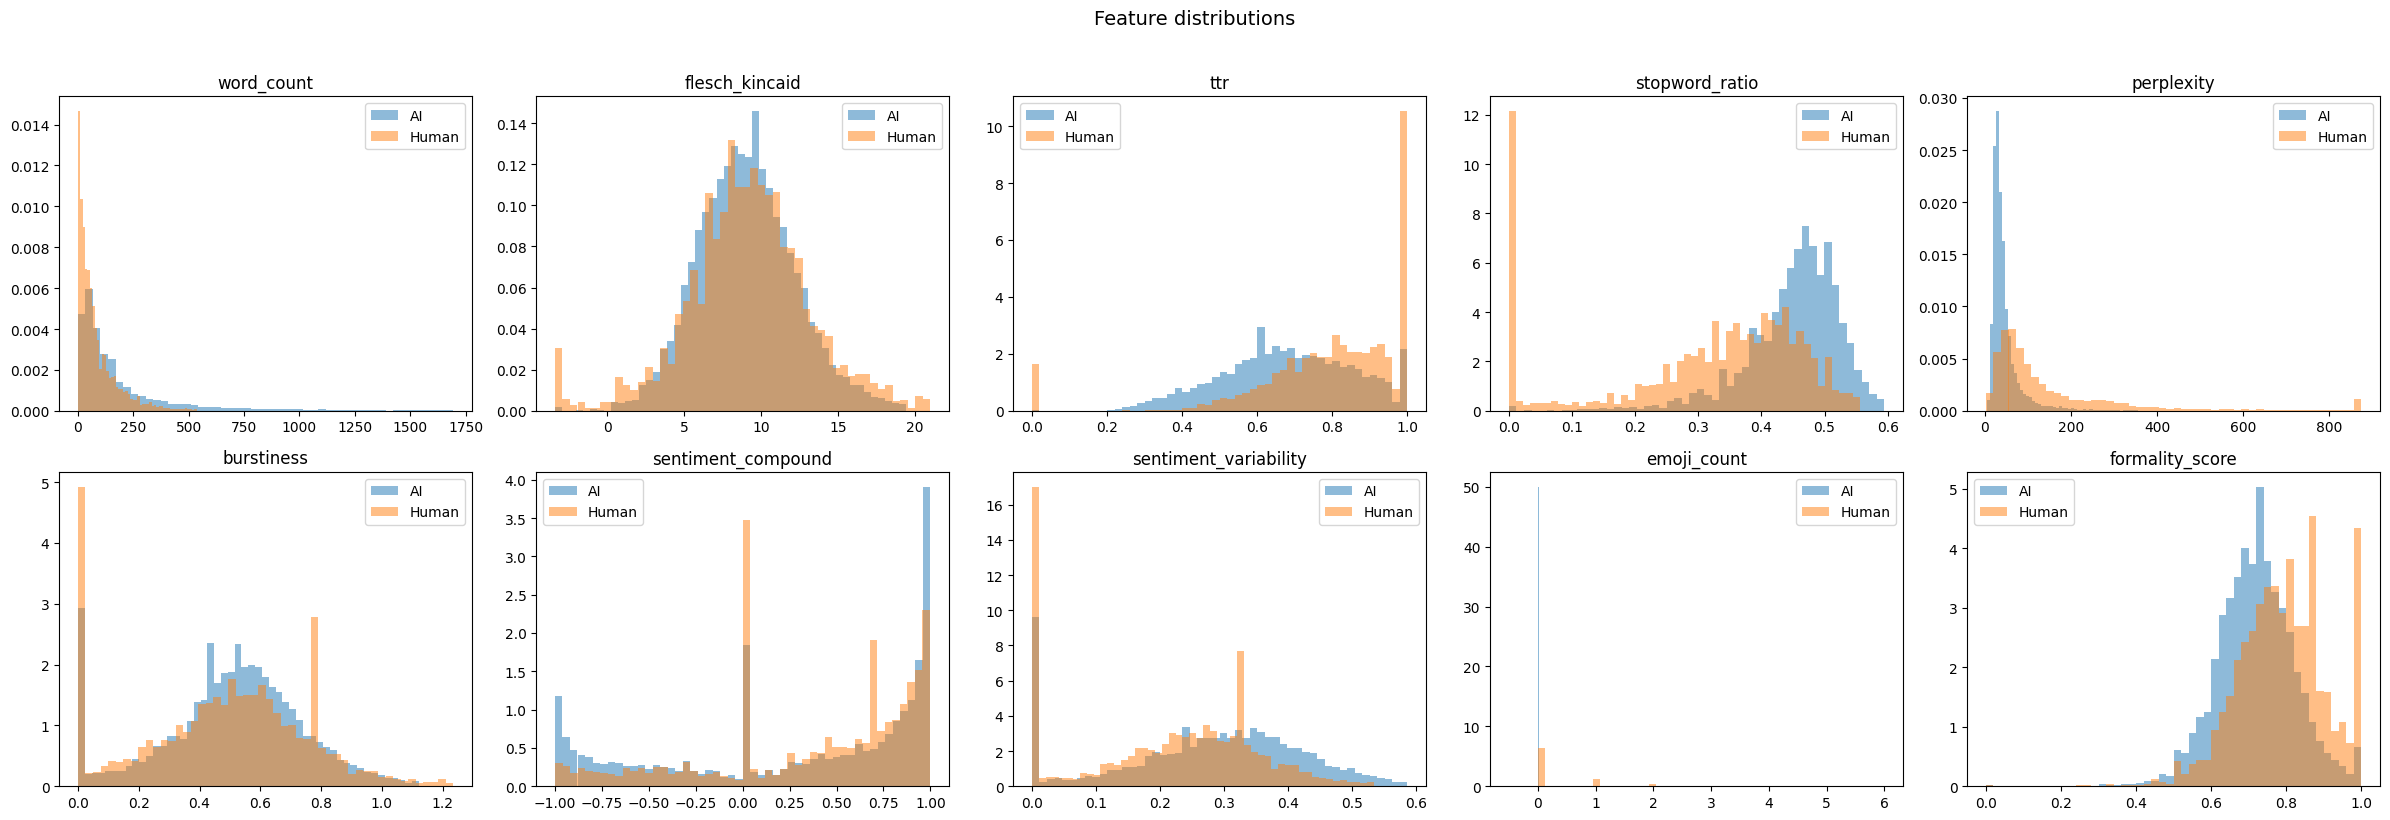

In [56]:

key_features = ['word_count', 'flesch_kincaid', 'ttr', 'stopword_ratio','perplexity', 'burstiness', 'sentiment_compound', 'sentiment_variability', 'emoji_count', 'formality_score']

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, name in [(1, 'AI'), (0, 'Human')]:
        data = df[df['label'] == label][feat].dropna()
        q99 = data.quantile(0.99)
        data = data[data <= q99]
        ax.hist(data, bins=50, alpha=0.5, label=name, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../graph_img/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:

comparison = df.groupby('label')[feature_cols].mean().T
comparison.columns = ['Human (0)', 'AI (1)']
comparison['AI/Human Ratio'] = comparison['AI (1)'] / (comparison['Human (0)'] + 1e-10)
comparison = comparison.sort_values('AI/Human Ratio', ascending=False)

print("Top features where AI > Human:")
print(comparison.head(15).to_string())
print("\nTop features where Human > AI:")
print(comparison.tail(15).to_string())

Top features where AI > Human:
                         Human (0)       AI (1)  AI/Human Ratio
upvotes                   0.548669   305.298431      556.434218
author_mean_upvotes       1.124231   197.535568      175.707248
inter_post_std            5.942572   290.119113       48.820463
inter_post_median        12.410993   586.745937       47.276308
trigram_repeat_rate       0.004516     0.015414        3.412941
ellipsis_count            0.069119     0.232943        3.370153
fourgram_repeat_rate      0.002416     0.007661        3.171453
hedging_per_100w          0.106428     0.266934        2.508110
word_count               91.324879   218.402639        2.391491
author_mean_hedging       0.096259     0.209520        2.176630
char_count              596.791570  1276.357819        2.138699
author_mean_word_count   90.791898   192.545940        2.120739
pos_VBD                   0.009622     0.018487        1.921348
self_reference_rate       0.015381     0.029202        1.898619
pos_CC   

## Processed Dataset

In [58]:
df['created_utc'] = df['created_utc'].astype(str)

tabular_cols = feature_cols + ['label', 'source', 'split']
all_feature_cols = feature_cols + emb_cols_list + ['label', 'source', 'split']

for split_name in ['train', 'val', 'test']:
    split_df = df[df['split'] == split_name].copy()
    split_df = split_df.reset_index(drop=True)
    
    # 1. Full Dataset with text metadata
    out_full = f"{DATA_DIR}/features_subset_{split_name}.parquet"
    split_df.to_parquet(out_full, index=False)
    
    # 2. Tabular Features Only
    out_tab = f"{DATA_DIR}/feature_matrix_subset_{split_name}.parquet"
    split_df[tabular_cols].to_parquet(out_tab, index=False)
    
    # 3. Tabular + Embeddings
    out_all = f"{DATA_DIR}/feature_matrix_full_subset_{split_name}.parquet"
    split_df[all_feature_cols].to_parquet(out_all, index=False)
    
    print(f"[{split_name.upper()}] Saved {len(split_df)} rows. Label dist: {split_df['label'].value_counts().to_dict()}")


[TRAIN] Saved 9541 rows. Label dist: {1: 5622, 0: 3919}
[VAL] Saved 2045 rows. Label dist: {1: 1205, 0: 840}
[TEST] Saved 2045 rows. Label dist: {1: 1205, 0: 840}
